In [2]:
###### pytorch로 cnn

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


In [5]:
transform=transforms.Compose([
    transforms.ToTensor(), 
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5,0.5))
])

train_data=datasets.CIFAR10('./data', train=True, download=True, transform=transform)
test_dat=datasets.CIFAR10('./data', train=False, transform=transform)



In [6]:
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dat, batch_size=64)

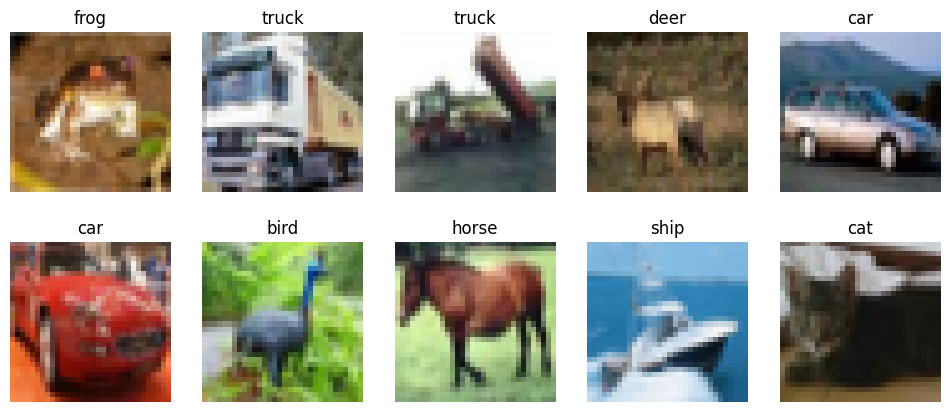

In [7]:
classes=['plane','car','bird','cat','deer','dog','frog','horse','ship','truck']
fig, axes=plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, label=train_data[i]

    ax.imshow(img.permute(1,2,0) * 0.5 + 0.5)
    ax.set_title(classes[label])
    ax.axis('off')
    
plt.show()


In [8]:
class SimpleCNN(nn.Module):
    
    def __init__(self):
        super().__init__()

        self.conv1=nn.Conv2d(3, 32, 3, padding=1)
        self.conv2=nn.Conv2d(32, 64, 3, padding=1)

        self.pool=nn.MaxPool2d(2, 2)

        self.fc1=nn.Linear(64 * 8 * 8, 256)
        self.fc2=nn.Linear(256, 10)

        self.relu=nn.ReLU()

    def forward(self, x):
        x=self.pool(self.relu(self.conv1(x)))
        x=self.pool(self.relu(self.conv2(x)))

        x=x.view(-1, 64 * 8 * 8)

        x=self.relu(self.fc1(x))
        x=self.fc2(x)

        return x

In [16]:
model = SimpleCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []
val_accs = []


In [24]:
def train(model, loader, criterion, optimizer, epoch):
    model.train()
    total_loss = 0
    for batch_idx, (data, target) in enumerate(loader):
        optimizer.zero_grad()       # 1. 기울기 초기화
        output = model(data)        # 2. 순전파
        loss = criterion(output, target)  # 3. 손실 계산
        loss.backward()             # 4. 역전파
        optimizer.step()            # 5. 파라미터 업데이트
        total_loss += loss.item()
    print(f'Epoch {epoch}: Loss = {total_loss/len(loader):.4f}')
    return total_loss / len(train_loader)
    

# 평가 함수
def evaluate(model, loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for data, target in loader:
            output = model(data)
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
    acc = 100. * correct / len(loader.dataset)
    print(f'Accuracy: {acc:.2f}%')
    return acc

In [26]:
for epoch in range(1, 6):
    loss=train(model, train_loader, criterion, optimizer, epoch)
    acc=evaluate(model, test_loader)

    train_losses.append(loss)
    val_accs.append(acc)

Epoch 1: Loss = 0.1671
Accuracy: 72.87%
Epoch 2: Loss = 0.1218
Accuracy: 72.18%
Epoch 3: Loss = 0.0934
Accuracy: 72.45%
Epoch 4: Loss = 0.0719
Accuracy: 72.19%
Epoch 5: Loss = 0.0710
Accuracy: 71.98%


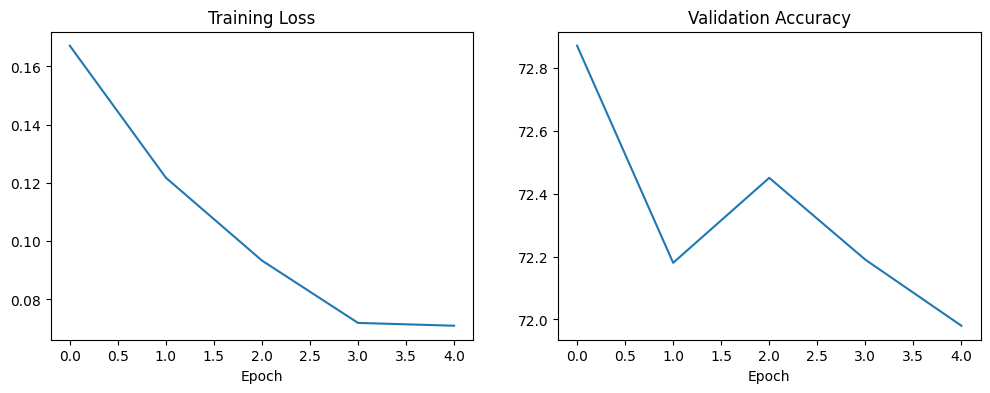

In [27]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.title('Training Loss')
plt.xlabel('Epoch')

plt.subplot(1, 2, 2)
plt.plot(val_accs)
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.savefig('training_curve.png')
plt.show()